### Models

In [66]:
import numpy as np
import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical
import math
import matplotlib
import matplotlib.pyplot as plt
import wandb

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

def positionalencoding2d(d_model, height, width):
    """
    :param d_model: dimension of the model
    :param height: height of the positions
    :param width: width of the positions
    :return: d_model*height*width position matrix
    """
    if d_model % 4 != 0:
        raise ValueError("Cannot use sin/cos positional encoding with "
                         "odd dimension (got dim={:d})".format(d_model))
    pe = torch.zeros(d_model, height, width)
    # Each dimension use half of d_model
    d_model = int(d_model / 2)
    div_term = torch.exp(torch.arange(0., d_model, 2) *
                         -(math.log(10000.0) / d_model))
    pos_w = torch.arange(0., width).unsqueeze(1)
    pos_h = torch.arange(0., height).unsqueeze(1)
    pe[0:d_model:2, :, :] = torch.sin(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[1:d_model:2, :, :] = torch.cos(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[d_model::2, :, :] = torch.sin(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)
    pe[d_model + 1::2, :, :] = torch.cos(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)

    return pe

def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer

class OutAttention(torch.nn.Module):
    def __init__(self, num_heads, embedding_dim, out_dim=64, 
                 tau=1.0, drop_prob=0.0):
        super(OutAttention, self).__init__()

        self.num_heads = num_heads
        self.out_dim = out_dim
        self.embedding_dim = embedding_dim

        self.d_k = out_dim // num_heads
        self.d_v = out_dim // num_heads

        self.Wv = torch.nn.Linear(out_dim, out_dim)

        self.Q = torch.rand((1, out_dim), device=DEVICE)

        self.layernorm = torch.nn.LayerNorm(out_dim)

        self.linear_out = nn.Sequential(
            nn.Linear(out_dim, 2*out_dim),
            nn.Dropout(drop_prob),
            nn.ReLU(),
            nn.Linear(2*out_dim, out_dim)
        )

    def forward(self, embeddings, generated_weights):
        batch = embeddings.size(0)
        seq_len = embeddings.size(1)
        embeddings = self.layernorm(embeddings)
        
        # Wq, Wk are shared across the minibatch: (out_dim, out_dim)
        Wq, Wk = generated_weights
        assert Wq.shape == Wk.shape == (self.out_dim, self.out_dim), f'{Wq.shape}'
        Q = (self.Q @ Wq).expand(batch, 1, self.out_dim)  # (1, out_dim) @ (out_dim, out_dim) -> (batch, 1, out_dim)
        K = embeddings @ Wk  # (batch, seq_len, out_dim) @ (out_dim, out_dim) -> (batch, seq_len, out_dim)
        assert K.shape == (batch, seq_len, self.out_dim), f'{K.shape}'
        V = self.Wv(embeddings)

        # Converting to multiheaded attention
        Q = Q.view(batch, 1, self.num_heads, self.d_k).transpose(1,2)  # (batch, num_heads, seq_len, d_k)
        assert Q.shape == (batch, self.num_heads, 1, self.d_k), f'{Q.shape}, {(batch, self.num_heads, seq_len, self.d_k)}'
        K = K.view(batch, seq_len, self.num_heads, self.d_k).transpose(1,2)  
        V = V.view(batch, seq_len, self.num_heads, self.d_v).transpose(1,2)  

        # Compute attention scores
        attention_scores = Q @ K.transpose(2,3)  # (num_heads, seq_len, seq_len)
        assert attention_scores.shape ==(batch, self.num_heads, 1, seq_len)

        # Scale the attention scores
        attention_scores = attention_scores / math.sqrt(self.d_k)

        # Apply softmax to get attention weights
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attention_weights = torch.nan_to_num(attention_weights, nan=0.0)
        assert attention_weights.shape == (batch, self.num_heads, 1, seq_len)

        self.attention_weights = attention_weights

        # Compute the output (weighted sum of values)
        output = attention_weights @ V
        assert output.shape == (batch, self.num_heads, 1, self.d_v), \
            f'{output.shape}, {(batch, self.num_heads, 1, self.d_v)}'

        output = output.transpose(1,2)
        output = output.flatten(start_dim=-2).squeeze(1)
        assert output.shape == (batch, self.out_dim)

        output = self.linear_out(output)
        return output

class ConditionedMultiHeadAttention(torch.nn.Module):
    def __init__(self, weight_gen_input_dim=2,dim=32,drop_prob=0.0):
        super(ConditionedMultiHeadAttention, self).__init__()
        self.dim = dim
        self.d_k = dim

        # One shared Wv
        self.Wv = nn.Linear(dim, dim)

        # Output FFNs
        self.linear1 = nn.Sequential(
            nn.Linear(dim, 2*dim),
            nn.Dropout(drop_prob),
            nn.ReLU(),
            nn.Linear(2*dim, dim)
        )
        self.linear2 = nn.Sequential(
            nn.Linear(dim, 2*dim),
            nn.Dropout(drop_prob),
            nn.ReLU(),
            nn.Linear(2*dim, dim)
        )

        self.layernorm1 = torch.nn.LayerNorm(dim)
        self.layernorm2 = torch.nn.LayerNorm(dim)

        self.dropout1 = torch.nn.Dropout(p=drop_prob)
        self.dropout2 = torch.nn.Dropout(p=drop_prob)
    
    def forward(self, embeddings, generated_weights):
        batch = embeddings.size(0)
        seq_len = embeddings.size(1)

        # Save for skip connection
        x0 = embeddings

        embeddings = self.layernorm1(embeddings)

        Wq, Wk = generated_weights
        assert Wq.shape == Wk.shape == (self.dim, self.dim), f'{Wq.shape}'
        Q = embeddings @ Wq  # (batch, seq_len, dim) @ (dim, dim) -> (batch, seq_len, dim)
        K = embeddings @ Wk
        assert Q.shape == K.shape == (batch, seq_len, self.dim)
        V = self.Wv(embeddings)

        # Compute attention scores
        attention_scores = Q @ K.transpose(1,2) / np.sqrt(self.d_k)  # (num_heads, seq_len, seq_len)
        assert attention_scores.shape ==(batch, seq_len, seq_len)
        
        attention_weights = torch.softmax(attention_scores, dim=-1)
        assert attention_weights.shape == (batch, seq_len, seq_len)
        self.attention_weights = attention_weights

        # Compute the output (weighted sum of values)
        output = attention_weights @ V
        assert output.shape == (batch, seq_len, self.dim)
        
        att_out = x0 + output
        mlp_out = self.linear1(self.layernorm2(att_out))
        att_out = att_out + mlp_out

        return att_out

class WeightGenerator(nn.Module):
    # Generates the Wq and Wk matrices for the attention network.
    def __init__(self, num_layers=1,input_dim=2,dim=32):
        super(WeightGenerator, self).__init__()
        self.num_layers = num_layers
        self.dim = dim
        self.input_dim=input_dim

        self.net = nn.Sequential(
                        nn.Linear(self.input_dim, 4*self.dim),
                        nn.ReLU(),
                        nn.Linear(4*self.dim, 8*self.dim),
                        nn.ReLU(),
                        nn.Linear(8*self.dim, (2*(self.num_layers+1) * self.dim*self.dim))
                    )
    def forward(self, z):
        assert z.shape == (self.input_dim,), f'expected a single condition vector, got {z.shape}'
        return self.net(z).reshape(2*(self.num_layers+1), self.dim, self.dim)


class TransformerAgent(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.dim = args.dim
        self.temp = args.temp
        self.weight_gen_input_dim = args.weight_gen_input_dim

        # Given an input, generates a Wq and Wk matrix for each attention layer, 
        # and a Wq,Wk matrix for the attention pooling layer.
        self.weight_generator = WeightGenerator(args.num_layers,args.weight_gen_input_dim,args.dim)

        # Token Extractor
        self.encoder = nn.Embedding(num_embeddings=args.num_embeddings, 
                                    embedding_dim=args.dim)

        self.w = args.width
        # Calculate the positional encodings
        sin_pos = positionalencoding2d(d_model=args.dim, height=self.w, width=self.w).to(DEVICE)
        sin_pos = torch.permute(sin_pos, (1,2,0)).flatten(start_dim=0, end_dim=1).unsqueeze(0)
        assert sin_pos.shape == (1, self.w*self.w, args.dim)
        self.pos = sin_pos

        # Define attention layers
        self.num_layers = args.num_layers
        self.MHA_layers = torch.nn.ModuleList([ConditionedMultiHeadAttention(
                                    weight_gen_input_dim=args.weight_gen_input_dim,dim=self.dim) 
                                    for _ in range(self.num_layers)])
        
        # Define aggregation function
        if args.aggregation == 'attention':
            self.agg_out = OutAttention(num_heads=1, 
                                        embedding_dim=self.dim, 
                                        out_dim=args.dim)
        elif args.aggregation == 'mean':
            self.agg_out = lambda x: (x.mean(dim=-2), torch.ones(x.shape[1], device=DEVICE), torch.ones(x.shape[1], device=DEVICE), torch.ones(x.shape[1], device=DEVICE))
        
        # Get max eta values for normalization; +I per layer accounts for the residual stream
        block = torch.ones((self.w*self.w,self.w*self.w), device=DEVICE) + torch.eye(self.w*self.w, device=DEVICE)
        eta = block
        for layer in self.MHA_layers[1:]:
            eta = block @ eta
        eta = torch.ones(self.w*self.w, device=DEVICE) @ eta
        self.max_eta = eta
    
        # Final output network: 1 logit for 'bce', 2 class logits for 'ce'
        self.loss_type = args.loss
        out_dim = 1 if args.loss == 'bce' else 2
        self.out_net = nn.Sequential(nn.Linear(args.dim, 256), nn.ReLU(), layer_init(nn.Linear(256, out_dim), std=0.01))

    def condition(self, c, device=DEVICE):
        # One-hot for condition index c, shared by the whole minibatch
        return nn.functional.one_hot(torch.tensor(c), num_classes=self.weight_gen_input_dim).float().to(device)

    def hidden(self, x, z):
        batch_size, _ = x.shape
        dim = self.dim
        w = self.w
        pos = self.pos.repeat((batch_size,1,1))

        # Extract feature tokens via CNN
        f = self.encoder(x.int())
        assert f.shape == (batch_size, w*w, dim), f'{f.shape}, {(batch_size, w*w, dim)}'
        
        # Add positional encodings
        f = f + pos

        # Attention layers: one Wq, Wk per layer for the whole minibatch
        w = self.weight_generator(z)
        assert w.shape == (2*(self.num_layers+1), dim, dim), w.shape
        out = f
        for i, layer in enumerate(self.MHA_layers):
            out = layer(out, w[2*i : 2*i+2])
            self.attention_weights = layer.attention_weights
        # Attention Aggregation
        out = self.agg_out(out,w[-2:])
        self.out_weights = self.agg_out.attention_weights
        return out

    def forward(self, x, z=None):
        h = self.hidden(x, z)
        logits = self.out_net(h)
        if self.loss_type == 'bce':
            return logits.squeeze(-1)  # (batch,) single logit for sigmoid + BCE
        return logits  # (batch, 2) class logits for softmax + cross-entropy
    
    def get_eta(self):
        # Attention flow from each input position to the output. +I per layer is the
        # residual connection, so information that skips a layer's attention still counts.
        eye = torch.eye(self.w*self.w, device=DEVICE).unsqueeze(0)
        o = self.MHA_layers[0].attention_weights + eye
        for layer in self.MHA_layers[1:]:
            o = (layer.attention_weights + eye) @ o
        out_w = self.agg_out.attention_weights.squeeze(1)
        o = out_w @ o
        return o

cpu


### Train

In [95]:
import numpy as np
import random
import torch
from torch import nn
import dill
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
from IPython.display import display
from sparse_generalization.utils.dataloading import get_shapes_datasets

from tqdm.auto import tqdm

class Args:
    batch_size:int = 256
    epochs:int = 500
    learning_rate:float = 5e-5
    max_grad_norm:float = 100.0

    val_fraction:float = 0.1
    num_val:int = 100
    num_train:int = 2000

    diversity_coef: float = 100.0
    div_type: str = 'abs'       
    div_margin: float = 0.05     # hinge for the bounded overlap losses: no push once per-example overlap <= margin
    entropy_coef: float = 0.0    
    sparsity_coef: float = 0.0

    weight_gen_input_dim:int = 2

    width:int = 5
    num_embeddings:int = 25

    num_layers:int = 3
    dim:int = 32
    temp:float = 1.0
    aggregation:str = 'attention'
    loss:str = 'ce'  
    seeds:tuple = (0, 1, 2)  

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def make_criterion(loss):
    # Returns (criterion, label caster, prediction -> class index) for the chosen loss.
    if loss == 'bce':
        return nn.BCEWithLogitsLoss(), lambda y: y.float(), lambda p: (p > 0).float()
    if loss == 'ce':
        return nn.CrossEntropyLoss(), lambda y: y.long(), lambda p: p.argmax(-1)
    raise ValueError(f"loss must be 'bce' or 'ce', got {loss!r}")

def normalize_mass(m, eps=1e-8):
    m = m.flatten(1)
    return m / (m.sum(-1, keepdim=True) + eps)

def entropy_loss(m, eps=1e-8):
    p = normalize_mass(m, eps)
    H = -(p * torch.log(p + eps)).sum(-1)
    return (H / math.log(p.shape[-1])).mean()

def div_abs(m1, m2):
    return -torch.abs(m1.flatten(1) - m2.flatten(1)).sum(-1)

def div_product(m1, m2):
    return (m1.flatten(1) * m2.flatten(1)).sum(-1)

def div_dice(m1, m2, eps=1e-6):
    m1, m2 = m1.flatten(1), m2.flatten(1)
    inter = torch.minimum(m1, m2).sum(-1)
    total = m1.sum(-1) + m2.sum(-1)
    return 2 * inter / (total + eps)

def div_cosine(m1, m2, eps=1e-8):
    return torch.nn.functional.cosine_similarity(m1.flatten(1), m2.flatten(1), dim=-1, eps=eps)

def div_jsd(m1, m2, eps=1e-8):
    p, q = normalize_mass(m1, eps), normalize_mass(m2, eps)
    mix = 0.5 * (p + q)
    kl = lambda a, b: (a * (torch.log(a + eps) - torch.log(b + eps))).sum(-1)
    jsd = 0.5 * kl(p, mix) + 0.5 * kl(q, mix)
    return -jsd

DIV_LOSSES = {'abs': div_abs, 'product': div_product, 'dice': div_dice, 'cosine': div_cosine, 'jsd': div_jsd}
BOUNDED_DIVS = {'jsd'}  

def diversity_loss_fn(m1, m2, kind, margin=0.0):
    if kind not in DIV_LOSSES:
        raise ValueError(f"div_type must be one of {list(DIV_LOSSES)}, got {kind!r}")
    # Returns (loss, raw): the hinged loss to optimise and the unhinged mean overlap for logging.
    overlap = DIV_LOSSES[kind](m1, m2)        
    raw = overlap.detach().mean()
    return overlap.mean(), raw

def train(args, seed=0):
    seed_everything(seed)
    args.num_embeddings = args.width * args.width

    data, val_sets, test_sets, anti_dataset = get_shapes_datasets(
        5000, '../data/shapes', args.width, False
    )

    X = data.x.flatten(start_dim=1)
    y = data.y.squeeze(-1)

    TEST_Xs = []; TEST_Ys = []
    for kind, id in [('test_a', 1), ('test_b', 2)]:
        TEST_Xs.append(test_sets[id].x)
        TEST_Ys.append(test_sets[id].y.squeeze(-1))

    # {0,1} labels: float for BCE, class indices for CE
    criterion, cast_y, to_pred = make_criterion(args.loss)
    y = cast_y(y)

    TEST_X = [d.flatten(start_dim=1) for d in TEST_Xs]
    TEST_y = [cast_y(d) for d in TEST_Ys]

    print("X shape:", X.shape)
    print("y shape:", y.shape)


    # Define datasets
    dataset = TensorDataset(X, y)
    test_datasets = [TensorDataset(tx,ty) for (tx,ty) in zip(TEST_X,TEST_y)]

    n_val = args.num_val
    n_train = args.num_train

    # Gather train and validation data from the training data
    train_dataset, val_dataset, _ = random_split(
        dataset,
        [n_train, n_val, len(dataset)-(n_train+n_val)],
        generator=torch.Generator().manual_seed(seed),
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=args.batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=args.batch_size,
        shuffle=False,
    )
    test_loaders = [DataLoader(
        ds,
        batch_size=args.batch_size,
        shuffle=False,
    ) for ds in test_datasets]


    # Model
    model=TransformerAgent(args).to(DEVICE)

    # Optimizer (criterion chosen above from args.loss)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate,
    )


    # Histories and plotting. Train acc/loss are logged every epoch, val acc every `val_every` epochs.
    val_every, plot_every = 100, 200
    train_acc_history, train_loss_history = [], []
    val_acc_history, val_epochs = [], []
    fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(11, 4))
    handle = None  # one persistent output for this seed's figure, updated in place

    # Training
    pbar = tqdm(range(args.epochs), desc=f"seed {seed}", leave=True)
    for epoch in pbar:
        # Linear LR annealing
        # for param_group in optimizer.param_groups:
        #     param_group['lr'] = args.learning_rate * (1-(epoch/args.epochs))
        model.train()

        train_loss = 0.0
        acc = 0.0
        div_running = 0.0
        div_raw_running = 0.0
        ent_running = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()

            z = model.condition(1)
            predictions = model(X_batch,z)  # (batch,) logit for bce, (batch, 2) logits for ce
            w1 = model.get_eta()
            loss1 = criterion(predictions, y_batch)
            acc+=(to_pred(predictions) == y_batch).float().sum().item()

            z = model.condition(0)
            predictions = model(X_batch,z)
            w2 = model.get_eta()
            loss2 = criterion(predictions, y_batch)
            acc+=(to_pred(predictions) == y_batch).float().sum().item()

            diversity_loss, div_raw = diversity_loss_fn(w1, w2, args.div_type, args.div_margin)
            ent_loss = entropy_loss(w1) + entropy_loss(w2)

            sparse_loss = torch.linalg.vector_norm(w1.sum(dim=-1).squeeze(-1), ord=0.5,dim=-1).mean() + \
                torch.linalg.vector_norm(w2.sum(dim=-1).squeeze(-1), ord=0.5, dim=-1).mean()
            
            loss = loss1 + loss2 + (args.diversity_coef*diversity_loss) + (args.sparsity_coef*sparse_loss) \
                + (args.entropy_coef*ent_loss)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=args.max_grad_norm)
            optimizer.step()

            train_loss += 0.5 * (loss1.item() + loss2.item()) * len(X_batch)
            div_running += diversity_loss.item() * len(X_batch)
            div_raw_running += div_raw.item() * len(X_batch)
            ent_running += ent_loss.item() * len(X_batch)

        acc /= 2*len(train_loader.dataset)
        train_loss /= len(train_loader.dataset)
        div_running /= len(train_loader.dataset)
        div_raw_running /= len(train_loader.dataset)
        ent_running /= len(train_loader.dataset)
        pbar.set_postfix(loss=f"{train_loss:.4f}", acc=f"{acc:.3f}",
                         div_raw=f"{div_raw_running:.4f}", ent=f"{ent_running:.3f}")
        train_acc_history.append(acc)
        train_loss_history.append(train_loss)

        # Every once in a while, log the accurac on the validation data.
        val_acc=0.0
        with torch.no_grad():
            if epoch % val_every == 0:
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(DEVICE)
                    y_batch = y_batch.to(DEVICE)
                    for c in range(args.weight_gen_input_dim):
                        predictions = model(X_batch, model.condition(c))
                        val_acc += (to_pred(predictions) == y_batch).float().sum().item()
                val_acc /= args.weight_gen_input_dim * len(val_loader.dataset)
                val_acc_history.append(val_acc)
                val_epochs.append(epoch)

        # Update the plot once in a while
        if epoch % plot_every == 0 or epoch == args.epochs - 1:
            epochs = range(len(train_acc_history))

            ax_acc.cla()
            ax_acc.plot(epochs, train_acc_history, lw=1.5, label="train (both conditions)")
            ax_acc.plot(val_epochs, val_acc_history, lw=1.5, marker="o", ms=4,
                        label=f"val (mean over conditions, every {val_every} ep)")
            ax_acc.set_title("Accuracy")
            ax_acc.set_xlabel("epoch")
            ax_acc.set_ylabel("accuracy")
            ax_acc.set_ylim(0, 1.02)
            ax_acc.legend(loc="lower right", frameon=False)

            ax_loss.cla()
            ax_loss.plot(epochs, train_loss_history, color="#2f6fdb", lw=1.5)
            ax_loss.set_title(f"Train {args.loss.upper()} loss (mean of both conditions)")
            ax_loss.set_xlabel("epoch")
            ax_loss.set_ylabel("loss")

            for a in (ax_acc, ax_loss):
                a.grid(alpha=0.3)
                a.spines[["top", "right"]].set_visible(False)
            fig.suptitle(f"seed {seed}  ·  epoch {epoch+1}/{args.epochs}  ·  div_coef={args.diversity_coef}  sparsity_coef={args.sparsity_coef}")
            fig.tight_layout()

            if handle is None:
                handle = display(fig, display_id=True)
            else:
                handle.update(fig)


    plt.close(fig)
    model.eval()

    val_acc=0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            for c in range(args.weight_gen_input_dim):
                predictions = model(X_batch, model.condition(c))
                val_acc += (to_pred(predictions) == y_batch).float().sum().item()
    val_acc /= args.weight_gen_input_dim * len(val_loader.dataset)

    # Test the model under both conditions on both sets of test data,
    # (each set of test data has a different solution)
    test_accs = []
    with torch.no_grad():
        for c in [0,1]:
            for i,test_loader in enumerate(test_loaders):
                acc = 0.0
                for X_batch, y_batch in test_loader:
                    X_batch = X_batch.to(DEVICE)
                    y_batch = y_batch.to(DEVICE)
                    predictions = model(X_batch, model.condition(c))
                    acc+=(to_pred(predictions) == y_batch).float().sum().item()
                test_accs.append(acc)
    test_accs = [t/len(test_loader.dataset) for t in test_accs]

    # Optionally, save the model 
    # torch.save(model.state_dict(), "model.pt")
    # print("Saved model.pt")

    return val_acc, test_accs, model

### Evaluation (CE)

seed 0
X shape: torch.Size([5000, 9])
y shape: torch.Size([5000])


seed 0:   0%|          | 0/4000 [00:00<?, ?it/s, acc=0.497, div_raw=-0.0057, ent=1.991, loss=0.6932]

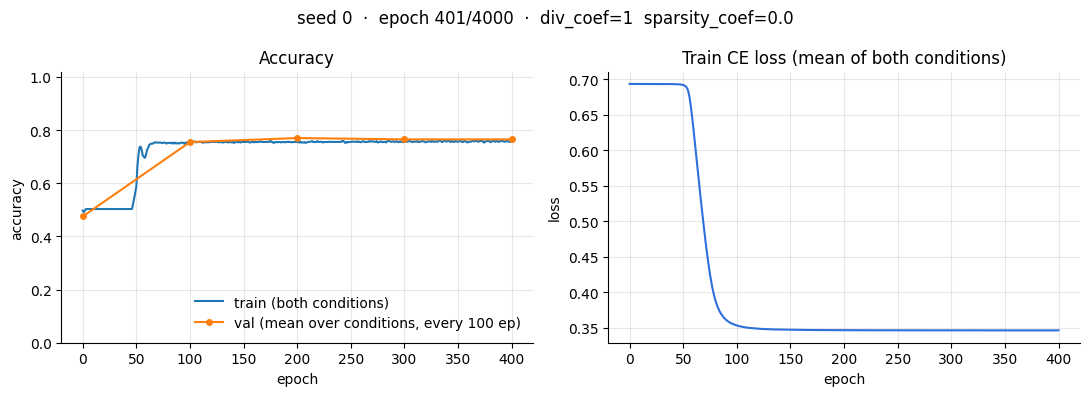

seed 0:  11%|█         | 435/4000 [06:15<51:15,  1.16it/s, acc=0.758, div_raw=-0.6931, ent=0.517, loss=0.3463]  


KeyboardInterrupt: 

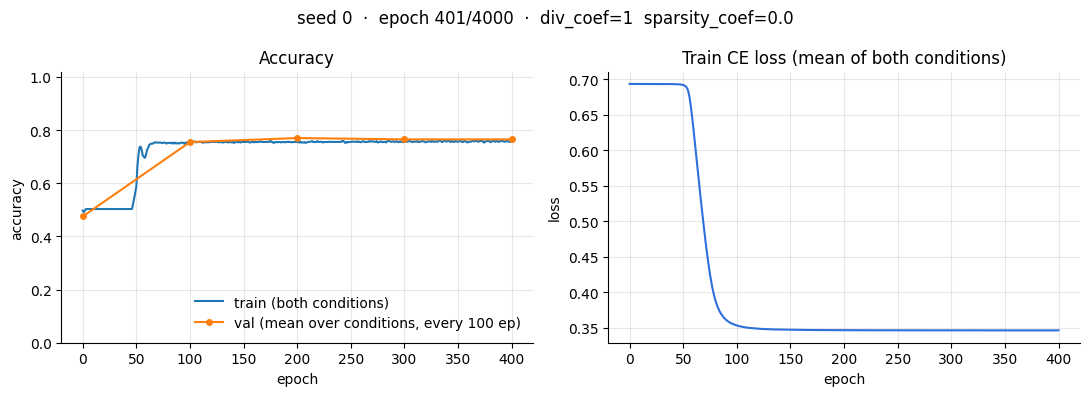

In [96]:
import torch
import numpy as np


args = Args()
args.batch_size = 128
args.epochs = 4000
args.learning_rate = 1e-5
args.max_grad_norm = 10000.0
args.num_val = 200
args.num_train = 4000

args.diversity_coef = 1
args.entropy_coef = 0.0
args.sparsity_coef = 0.0
args.rep_coef = 0.0
args.loss = 'ce'  
args.width = 3
args.num_layers = 3
args.div_type = 'jsd'

val_acc, test_accs = [],[]
for seed in args.seeds:
    print(f"seed {seed}")
    a,b,_= train(args, seed=seed)
    print(f"val acc: {a} | test accs: {b}")
    val_acc.append(a)
    test_accs.append(b)

In [11]:
val = np.array(val_acc)
test = np.array(test_accs).reshape(len(test_accs), 2, 2)

print(f"val acc (mean over conditions): {val.mean():.3f} ± {val.std():.3f}  over {len(val)} runs\n")

header = f"{'seed':>4} | {'cond 0: test_a':>14} {'test_b':>7} | {'cond 1: test_a':>14} {'test_b':>7}"
print(header)
print("-" * len(header))
for r, acc in zip(args.seeds, test):
    print(f"{r:>4} | {acc[0, 0]:>14.3f} {acc[0, 1]:>7.3f} | {acc[1, 0]:>14.3f} {acc[1, 1]:>7.3f}")
print("-" * len(header))
m = test.mean(0)
print(f"{'mean':>4} | {m[0, 0]:>14.3f} {m[0, 1]:>7.3f} | {m[1, 0]:>14.3f} {m[1, 1]:>7.3f}")

best_a = test[:, :, 0].max(1)
best_b = test[:, :, 1].max(1)
print(f"\nbest condition per set:  test_a {best_a.mean():.3f} ± {best_a.std():.3f}   test_b {best_b.mean():.3f} ± {best_b.std():.3f}")


val acc (mean over conditions): 1.000 ± 0.000  over 3 runs

seed | cond 0: test_a  test_b | cond 1: test_a  test_b
------------------------------------------------------
   0 |          0.500   0.997 |          0.500   1.000
   1 |          0.910   0.514 |          0.875   0.529
   2 |          0.831   0.608 |          0.740   0.622
------------------------------------------------------
mean |          0.747   0.706 |          0.705   0.717

best condition per set:  test_a 0.747 ± 0.178   test_b 0.717 ± 0.204


### Evaluation (BCE)

seed 0 | val accs so far: []
X shape: torch.Size([5000, 25])
y shape: torch.Size([5000])


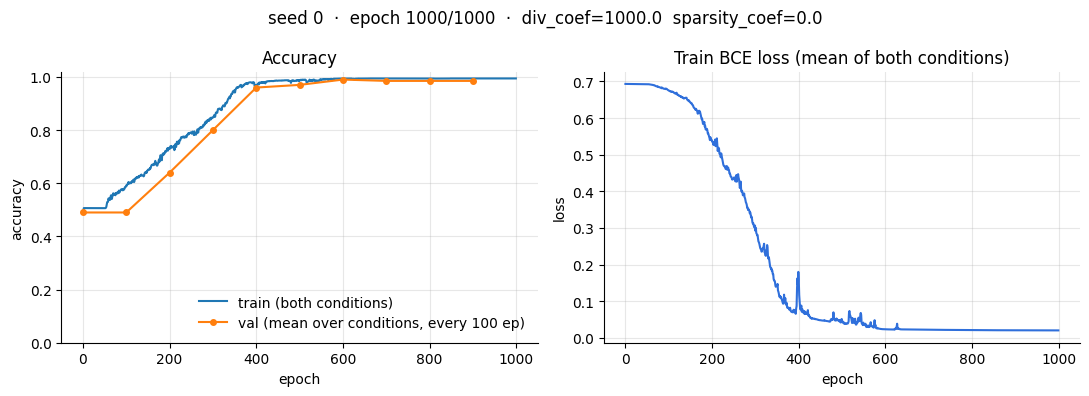

seed 1 | val accs so far: [0.985]
X shape: torch.Size([5000, 25])
y shape: torch.Size([5000])


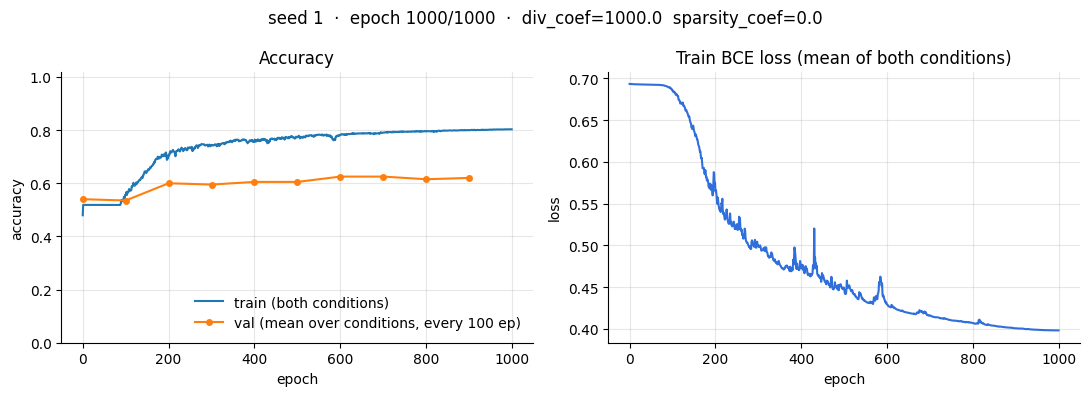

seed 2 | val accs so far: [0.985, 0.625]
X shape: torch.Size([5000, 25])
y shape: torch.Size([5000])


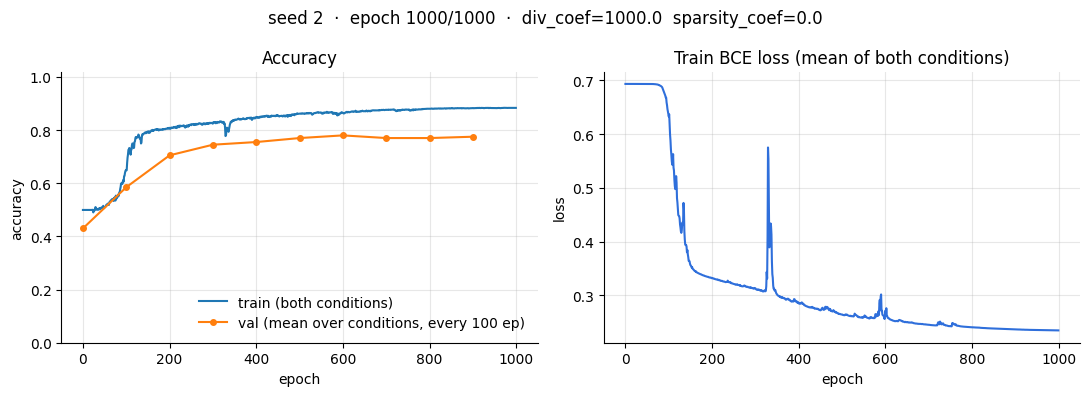

In [5]:
import torch
import numpy as np


args = Args()
args.batch_size = 512
args.epochs = 1000
args.learning_rate = 5e-5
args.max_grad_norm = 100.0
args.num_train = 2000

args.diversity_coef = 1000.0
args.sparsity_coef = 0.0
args.loss = 'bce'  
args.width = 5
args.num_layers = 3

val_acc, test_accs = [],[]
for seed in args.seeds:
    print(f"seed {seed} | val accs so far: {val_acc}")
    a,b,_=train(args, seed=seed)
    val_acc.append(a)
    test_accs.append(b)

In [6]:
val = np.array(val_acc)
test = np.array(test_accs).reshape(len(test_accs), 2, 2)

print(f"val acc (mean over conditions): {val.mean():.3f} ± {val.std():.3f}  over {len(val)} runs\n")

header = f"{'run':>4} | {'cond 0: test_a':>14} {'test_b':>7} | {'cond 1: test_a':>14} {'test_b':>7}"
print(header)
print("-" * len(header))
for r, acc in enumerate(test):
    print(f"{r:>4} | {acc[0, 0]:>14.3f} {acc[0, 1]:>7.3f} | {acc[1, 0]:>14.3f} {acc[1, 1]:>7.3f}")
print("-" * len(header))
m = test.mean(0)
print(f"{'mean':>4} | {m[0, 0]:>14.3f} {m[0, 1]:>7.3f} | {m[1, 0]:>14.3f} {m[1, 1]:>7.3f}")

best_a = test[:, :, 0].max(1)
best_b = test[:, :, 1].max(1)
print(f"\nbest condition per set:  test_a {best_a.mean():.3f} ± {best_a.std():.3f}   test_b {best_b.mean():.3f} ± {best_b.std():.3f}")


val acc (mean over conditions): 0.797 ± 0.147  over 3 runs

 run | cond 0: test_a  test_b | cond 1: test_a  test_b
------------------------------------------------------
   0 |          0.778   0.515 |          0.994   0.500
   1 |          0.503   0.650 |          0.501   0.507
   2 |          0.500   0.979 |          0.512   0.559
------------------------------------------------------
mean |          0.594   0.715 |          0.669   0.522

best condition per set:  test_a 0.670 ± 0.229   test_b 0.715 ± 0.195


### No diversity loss

X shape: torch.Size([5000, 25])
y shape: torch.Size([5000])


seed 3:   0%|          | 0/300 [00:00<?, ?it/s, acc=0.502, div=-0.8679, loss=0.6932]

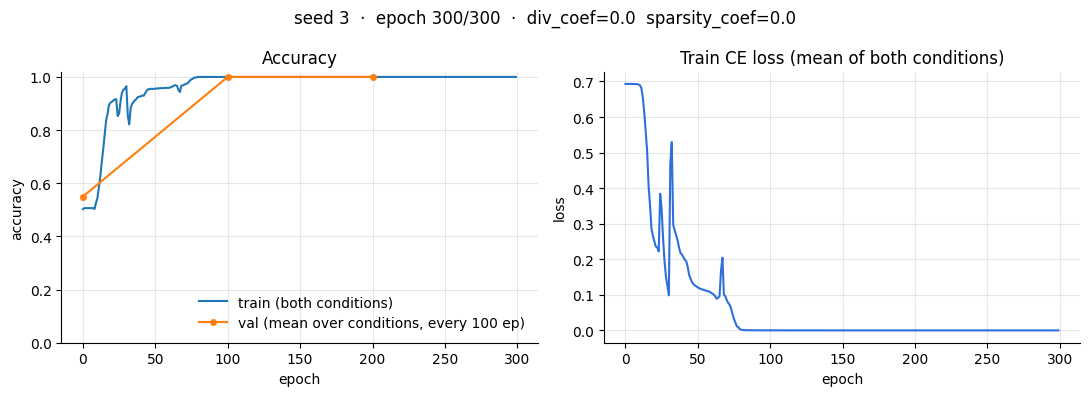

seed 3: 100%|██████████| 300/300 [02:27<00:00,  2.04it/s, acc=1.000, div=-0.4786, loss=0.0000]


val acc (mean over conditions): 1.000
test accs [cond 0: test_a, test_b | cond 1: test_a, test_b]: [0.5, 0.989, 0.5, 0.987]


In [46]:
import torch
import numpy as np

args = Args()
args.batch_size = 512
args.epochs = 300
args.learning_rate = 3e-4   
args.max_grad_norm = 100.0
args.num_train = 3000

args.diversity_coef = 0.0   
args.sparsity_coef = 0.0
args.loss = 'ce'
args.width = 5
args.num_layers = 3


val_acc_nodiv, test_accs_nodiv, model_nodiv = train(args, seed=3)
print(f"val acc (mean over conditions): {val_acc_nodiv:.3f}")
print(f"test accs [cond 0: test_a, test_b | cond 1: test_a, test_b]: {[round(t, 3) for t in test_accs_nodiv]}")


Averaged over 1000 in-distribution test examples
cond |          eta mass on           | prediction flips when pair is broken (pos / neg)
     |     star/heart   circle/square |              star/heart            circle/square
------------------------------------------------------------------------------------------
   0 |       12779.25        45765.46 |        0.14 / 0.01              1.00 / 0.00     
   1 |       12392.50        46206.75 |        0.14 / 0.01              1.00 / 0.00     


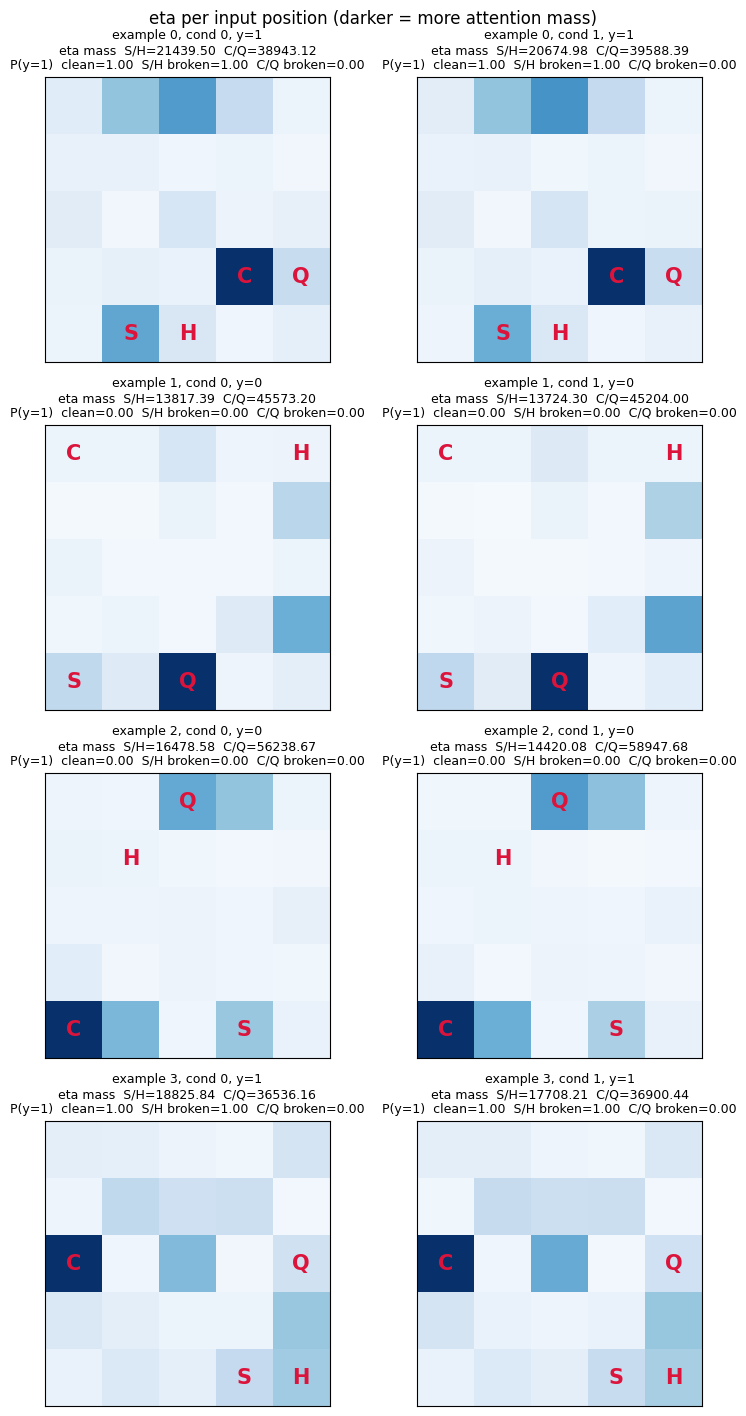

In [47]:
from sparse_generalization.data.shapes.constants import SHAPES_TO_IDX

PAIRS = {'star/heart':    [SHAPES_TO_IDX['star'],   SHAPES_TO_IDX['heart']],    
         'circle/square': [SHAPES_TO_IDX['circle'], SHAPES_TO_IDX['square']]}   
LETTERS = {SHAPES_TO_IDX['star']: 'S', SHAPES_TO_IDX['heart']: 'H', SHAPES_TO_IDX['circle']: 'C', SHAPES_TO_IDX['square']: 'Q'}

model = model_nodiv
model.eval()

def eta_per_token(x, c):
    with torch.no_grad():
        model(x, model.condition(c))
        return model.get_eta().squeeze(1) * model.max_eta[0]

def p_positive(x, c):
    with torch.no_grad():
        logits = model(x, model.condition(c))
        return torch.sigmoid(logits) if model.loss_type == 'bce' else torch.softmax(logits, -1)[:, 1]

def on_pair(x, ids):
    return torch.isin(x, torch.tensor(ids, dtype=x.dtype))

def broken(x, ids, seed=0):
    g = torch.Generator().manual_seed(seed)
    x = x.clone()
    w = args.width
    first = (x == ids[0]).float().argmax(-1); second = (x == ids[1]).float().argmax(-1)
    for i in range(len(x)):
        cells = [j for j in range(w * w) if j // w != first[i].item() // w and j != second[i].item()]
        j = cells[torch.randint(len(cells), (1,), generator=g).item()]
        x[i, second[i]], x[i, j] = x[i, j].item(), x[i, second[i]].item()
    return x

_, _, test_sets_all, _ = get_shapes_datasets(5000, '../data/shapes', args.width, False)
idx = torch.randperm(len(test_sets_all[0]), generator=torch.Generator().manual_seed(0))[:1000]
X_id = test_sets_all[0].x.flatten(start_dim=1)[idx]
y_id = test_sets_all[0].y.squeeze(-1)[idx]

print("Averaged over 1000 in-distribution test examples")
print(f"{'cond':>4} | {'eta mass on':^30} | {'prediction flips when pair is broken (pos / neg)':^48}")
print(f"{'':>4} | {'star/heart':>14} {'circle/square':>15} | {'star/heart':>23} {'circle/square':>24}")
print("-" * 90)
pos, neg = y_id == 1, y_id == 0
for c in range(2):
    eta = eta_per_token(X_id, c)
    pred = p_positive(X_id, c) > 0.5
    mass = [(eta * on_pair(X_id, ids)).sum(-1).mean().item() for ids in PAIRS.values()]
    flips = []
    for ids in PAIRS.values():
        flipped = (p_positive(broken(X_id, ids), c) > 0.5) != pred
        flips.append((flipped[pos].float().mean().item(), flipped[neg].float().mean().item()))
    print(f"{c:>4} | {mass[0]:>14.2f} {mass[1]:>15.2f} | "
          f"{flips[0][0]:>11.2f} / {flips[0][1]:<9.2f} {flips[1][0]:>12.2f} / {flips[1][1]:<9.2f}")

n_show = 4
fig, axes = plt.subplots(n_show, 2, figsize=(8, 3.6 * n_show))
for r in range(n_show):
    x = X_id[r:r + 1]
    for c in range(2):
        ax = axes[r, c]
        eta = eta_per_token(x, c)[0]
        ax.imshow(eta.view(args.width, args.width), cmap='Blues', vmin=0, vmax=max(eta.max().item(), 1e-6))
        for pos, tok in enumerate(x[0].tolist()):
            if int(tok) in LETTERS:
                ax.text(pos % args.width, pos // args.width, LETTERS[int(tok)],
                        ha='center', va='center', fontsize=15, color='crimson', weight='bold')
        mass = {name: (eta * on_pair(x, ids)[0]).sum().item() for name, ids in PAIRS.items()}
        p_clean = p_positive(x, c).item()
        p_broken = {name: p_positive(broken(x, ids, seed=r), c).item() for name, ids in PAIRS.items()}
        ax.set_title(f"example {r}, cond {c}, y={int(y_id[r])}\n"
                     f"eta mass  S/H={mass['star/heart']:.2f}  C/Q={mass['circle/square']:.2f}\n"
                     f"P(y=1)  clean={p_clean:.2f}  S/H broken={p_broken['star/heart']:.2f}  C/Q broken={p_broken['circle/square']:.2f}",
                     fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("eta per input position (darker = more attention mass)")
fig.tight_layout()
plt.show()


### Masked models

In [99]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


def gumbel_edge_mask(logits, temp=1.0, bias=0.5, hard=True):
    # SPARTAN's edge sampler: independent binary gumbel-softmax per attention entry,
    # over the 2-class logits [0, logit + bias]. hard=True gives straight-through {0,1}.
    shape = logits.shape
    flat = logits.reshape(shape[0], -1)
    edges = torch.stack([torch.zeros_like(flat), flat + bias], dim=-1)
    return F.gumbel_softmax(edges, tau=temp, hard=hard)[..., -1].view(shape)


class MaskedMultiHeadAttention(torch.nn.Module):
    def __init__(self, weight_gen_input_dim=2, dim=32, drop_prob=0.0, temp=1.0, bias=0.5):
        super(MaskedMultiHeadAttention, self).__init__()
        self.dim = dim
        self.d_k = dim
        self.temp = temp
        self.bias = bias

        # One shared Wv
        self.Wv = nn.Linear(dim, dim)

        # Output FFNs
        self.linear1 = nn.Sequential(
            nn.Linear(dim, 2*dim),
            nn.Dropout(drop_prob),
            nn.ReLU(),
            nn.Linear(2*dim, dim)
        )
        self.linear2 = nn.Sequential(
            nn.Linear(dim, 2*dim),
            nn.Dropout(drop_prob),
            nn.ReLU(),
            nn.Linear(2*dim, dim)
        )

        self.layernorm1 = torch.nn.LayerNorm(dim)
        self.layernorm2 = torch.nn.LayerNorm(dim)

        self.dropout1 = torch.nn.Dropout(p=drop_prob)
        self.dropout2 = torch.nn.Dropout(p=drop_prob)

    def forward(self, embeddings, generated_weights):
        batch = embeddings.size(0)
        seq_len = embeddings.size(1)

        # Save for skip connection
        x0 = embeddings

        embeddings = self.layernorm1(embeddings)

        Wq, Wk = generated_weights
        assert Wq.shape == Wk.shape == (self.dim, self.dim), f'{Wq.shape}'
        Q = embeddings @ Wq
        K = embeddings @ Wk
        assert Q.shape == K.shape == (batch, seq_len, self.dim)
        V = self.Wv(embeddings)

        attention_scores = Q @ K.transpose(1,2) / np.sqrt(self.d_k)
        assert attention_scores.shape == (batch, seq_len, seq_len)

        attention_probs = torch.softmax(attention_scores, dim=-1).clamp(0.001, 0.999)

        A = gumbel_edge_mask(attention_scores, self.temp, self.bias)
        masked_probs = A * attention_probs

        self.mask = A
        self.attention_weights = masked_probs
        self.raw_attention_weights = attention_probs

        output = masked_probs @ V
        assert output.shape == (batch, seq_len, self.dim)

        att_out = x0 + output
        mlp_out = self.linear1(self.layernorm2(att_out))
        att_out = att_out + mlp_out

        return att_out


class MaskedOutAttention(torch.nn.Module):
    def __init__(self, num_heads, embedding_dim, out_dim=64,
                 tau=1.0, drop_prob=0.0, temp=1.0, bias=0.5):
        super(MaskedOutAttention, self).__init__()

        self.num_heads = num_heads
        self.out_dim = out_dim
        self.embedding_dim = embedding_dim
        self.temp = temp
        self.bias = bias

        self.d_k = out_dim // num_heads
        self.d_v = out_dim // num_heads

        self.Wv = torch.nn.Linear(out_dim, out_dim)

        self.Q = torch.rand((1, out_dim), device=DEVICE)

        self.layernorm = torch.nn.LayerNorm(out_dim)

        self.linear_out = nn.Sequential(
            nn.Linear(out_dim, 2*out_dim),
            nn.Dropout(drop_prob),
            nn.ReLU(),
            nn.Linear(2*out_dim, out_dim)
        )

    def forward(self, embeddings, generated_weights):
        batch = embeddings.size(0)
        seq_len = embeddings.size(1)
        embeddings = self.layernorm(embeddings)

        Wq, Wk = generated_weights
        assert Wq.shape == Wk.shape == (self.out_dim, self.out_dim), f'{Wq.shape}'
        Q = (self.Q @ Wq).expand(batch, 1, self.out_dim)
        K = embeddings @ Wk
        assert K.shape == (batch, seq_len, self.out_dim), f'{K.shape}'
        V = self.Wv(embeddings)

        Q = Q.view(batch, 1, self.num_heads, self.d_k).transpose(1,2)
        K = K.view(batch, seq_len, self.num_heads, self.d_k).transpose(1,2)
        V = V.view(batch, seq_len, self.num_heads, self.d_v).transpose(1,2)

        attention_scores = Q @ K.transpose(2,3) / math.sqrt(self.d_k)
        assert attention_scores.shape == (batch, self.num_heads, 1, seq_len)

        attention_weights = torch.softmax(attention_scores, dim=-1)
        attention_weights = torch.nan_to_num(attention_weights, nan=0.0).clamp(0.001, 0.999)

        # SPARTAN masking on the aggregation step as well
        A = gumbel_edge_mask(attention_scores, self.temp, self.bias)
        masked_weights = A * attention_weights

        self.mask = A
        self.attention_weights = masked_weights
        self.raw_attention_weights = attention_weights

        output = masked_weights @ V
        assert output.shape == (batch, self.num_heads, 1, self.d_v)

        output = output.transpose(1,2)
        output = output.flatten(start_dim=-2).squeeze(1)
        assert output.shape == (batch, self.out_dim)

        return self.linear_out(output)


class MaskedTransformerAgent(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.dim = args.dim
        self.temp = getattr(args, 'start_temp', args.temp)
        self.bias = getattr(args, 'mask_bias', 0.5)
        self.weight_gen_input_dim = args.weight_gen_input_dim

        self.weight_generator = WeightGenerator(args.num_layers, args.weight_gen_input_dim, args.dim)

        self.encoder = nn.Embedding(num_embeddings=args.num_embeddings,
                                    embedding_dim=args.dim)

        self.w = args.width
        sin_pos = positionalencoding2d(d_model=args.dim, height=self.w, width=self.w).to(DEVICE)
        sin_pos = torch.permute(sin_pos, (1,2,0)).flatten(start_dim=0, end_dim=1).unsqueeze(0)
        assert sin_pos.shape == (1, self.w*self.w, args.dim)
        self.pos = sin_pos

        self.num_layers = args.num_layers
        self.MHA_layers = torch.nn.ModuleList([MaskedMultiHeadAttention(
                                    weight_gen_input_dim=args.weight_gen_input_dim, dim=self.dim,
                                    temp=self.temp, bias=self.bias)
                                    for _ in range(self.num_layers)])

        assert args.aggregation == 'attention', "masked model needs attention aggregation"
        self.agg_out = MaskedOutAttention(num_heads=1,
                                          embedding_dim=self.dim,
                                          out_dim=args.dim,
                                          temp=self.temp, bias=self.bias)

        # Get max eta values for normalization; +I per layer accounts for the residual stream
        block = torch.ones((self.w*self.w,self.w*self.w), device=DEVICE) + torch.eye(self.w*self.w, device=DEVICE)
        eta = block
        for layer in self.MHA_layers[1:]:
            eta = block @ eta
        eta = torch.ones(self.w*self.w, device=DEVICE) @ eta
        self.max_eta = eta

        self.max_paths, self.max_path = self._compute_max_paths(self.w*self.w)

        self.loss_type = args.loss
        out_dim = 1 if args.loss == 'bce' else 2
        self.out_net = nn.Sequential(nn.Linear(args.dim, 256), nn.ReLU(), layer_init(nn.Linear(256, out_dim), std=0.01))

    def _compute_max_paths(self, seq_len):
        # Path count with every edge kept; +I per layer accounts for the residual stream.
        block = torch.ones((seq_len, seq_len), device=DEVICE) + torch.eye(seq_len, device=DEVICE)
        paths = block
        for _ in range(self.num_layers - 1):
            paths = paths @ block
        paths = torch.ones((1, seq_len), device=DEVICE) @ paths
        return paths.sum().item(), paths

    def condition(self, c, device=DEVICE):
        return nn.functional.one_hot(torch.tensor(c), num_classes=self.weight_gen_input_dim).float().to(device)

    def hidden(self, x, z):
        batch_size, _ = x.shape
        dim = self.dim
        w = self.w
        pos = self.pos.repeat((batch_size,1,1))

        f = self.encoder(x.int())
        assert f.shape == (batch_size, w*w, dim), f'{f.shape}, {(batch_size, w*w, dim)}'

        f = f + pos

        w = self.weight_generator(z)
        assert w.shape == (2*(self.num_layers+1), dim, dim), w.shape
        out = f
        for i, layer in enumerate(self.MHA_layers):
            out = layer(out, w[2*i : 2*i+2])
            self.attention_weights = layer.attention_weights
        out = self.agg_out(out, w[-2:])
        self.out_weights = self.agg_out.attention_weights
        return out

    def forward(self, x, z=None):
        h = self.hidden(x, z)
        logits = self.out_net(h)
        if self.loss_type == 'bce':
            return logits.squeeze(-1)
        return logits

    def get_eta(self):
        eye = torch.eye(self.w*self.w, device=DEVICE).unsqueeze(0)
        o = self.MHA_layers[0].attention_weights + eye
        for layer in self.MHA_layers[1:]:
            o = (layer.attention_weights + eye) @ o
        out_w = self.agg_out.attention_weights.squeeze(1)
        o = out_w @ o
        return o

    def get_path_mask(self, normalize=False):
        eye = torch.eye(self.w*self.w, device=DEVICE).unsqueeze(0)
        paths = self.MHA_layers[0].mask + eye
        for layer in self.MHA_layers[1:]:
            paths = (layer.mask + eye) @ paths
            
        out = (self.agg_out.mask.squeeze(1) @ paths) / self.max_path if normalize else self.agg_out.mask.squeeze(1) @ paths
        return out

    def _enforce_sparsity(self, paths, alpha):
        num_edges = paths.sum(dim=(-2, -1)) / self.max_paths
        return (alpha - num_edges).pow(2).mean()

    def edge_density(self):
        return self.get_path_mask().sum(dim=(-2,-1)) / self.max_paths

    def temp_decay(self, step, total_steps, start_temp=3.0, end_temp=0.1):
        temp = max(start_temp - (step / max(total_steps, 1)) * (start_temp - end_temp), end_temp)
        self.temp = temp
        for layer in self.MHA_layers:
            layer.temp = temp
        self.agg_out.temp = temp
        return temp

### Train (masked)

In [101]:
from tqdm.auto import tqdm

class MaskedArgs(Args):
    start_temp: float = 3.0       # gumbel temperature at epoch 0
    end_temp: float = 0.1         # annealed to this by the last epoch
    mask_bias: float = 0.5        # logit bias; >0 keeps most edges alive at init
    target_density: float = 0.1   # fraction of max paths the sparsity loss aims for
    sparsity_coef: float = 1.0
    div_type: str = 'dice'        # diversity loss on the path masks; see DIV_LOSSES


def train_masked(args, seed=0):
    # Copy of train(), with the masked model, temperature annealing and a sparsity
    # loss that acts on the binary masks instead of on eta.
    seed_everything(seed)
    args.num_embeddings = args.width * args.width

    data, val_sets, test_sets, anti_dataset = get_shapes_datasets(
        5000, '../data/shapes', args.width, False
    )

    X = data.x.flatten(start_dim=1)
    y = data.y.squeeze(-1)

    TEST_Xs = []; TEST_Ys = []
    for kind, id in [('test_a', 1), ('test_b', 2)]:
        TEST_Xs.append(test_sets[id].x)
        TEST_Ys.append(test_sets[id].y.squeeze(-1))

    criterion, cast_y, to_pred = make_criterion(args.loss)
    y = cast_y(y)

    TEST_X = [d.flatten(start_dim=1) for d in TEST_Xs]
    TEST_y = [cast_y(d) for d in TEST_Ys]

    dataset = TensorDataset(X, y)
    test_datasets = [TensorDataset(tx, ty) for (tx, ty) in zip(TEST_X, TEST_y)]

    n_val = args.num_val
    n_train = args.num_train

    train_dataset, val_dataset, _ = random_split(
        dataset,
        [n_train, n_val, len(dataset)-(n_train+n_val)],
        generator=torch.Generator().manual_seed(seed),
    )
    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False)
    test_loaders = [DataLoader(ds, batch_size=args.batch_size, shuffle=False) for ds in test_datasets]

    model = MaskedTransformerAgent(args).to(DEVICE)
    print("max paths:", model.max_paths)
    print("max eta:", model.max_eta)

    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    val_every, plot_every = 100, 200
    train_acc_history, train_loss_history, density_history = [], [], []
    val_acc_history, val_epochs = [], []
    fig, (ax_acc, ax_loss, ax_den) = plt.subplots(1, 3, figsize=(15, 4))
    handle = None

    pbar = tqdm(range(args.epochs), desc=f"seed {seed}", leave=True)
    for epoch in pbar:
        # temp = model.temp_decay(epoch, args.epochs, args.start_temp, args.end_temp)
        model.train()

        train_loss = 0.0
        acc = 0.0
        density = 0.0
        den1 = 0.0
        den2 = 0.0
        div_running = 0.0
        div_raw_running = 0.0
        ent_running = 0.0
        sparse_running = 0.0
        mask1_running = 0.0
        mask2_running = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()

            z = model.condition(0)
            predictions = model(X_batch, z)
            w1 = model.get_eta()
            m1 = model.get_path_mask(normalize=False)
            m1_paths = m1 / model.max_path
            with torch.no_grad():
                m1_un = model.get_path_mask(normalize=False).detach()
            loss1 = criterion(predictions, y_batch)
            acc += (to_pred(predictions) == y_batch).float().sum().item()

            z = model.condition(1)
            predictions = model(X_batch, z)
            w2 = model.get_eta()
            m2 = model.get_path_mask(normalize=False)
            m2_paths = m2 / model.max_path
            with torch.no_grad():
                m2_un = model.get_path_mask(normalize=False).detach()
            loss2 = criterion(predictions, y_batch)
            acc += (to_pred(predictions) == y_batch).float().sum().item()

            # SPARTAN sparsity: push the surviving path fraction towards target_density
            with torch.no_grad():
                edges1 = m1_un.sum(dim=(-2, -1)) / model.max_paths
                edges2 = m2_un.sum(dim=(-2, -1)) / model.max_paths
                        
            sparse_loss = model._enforce_sparsity(m1, args.target_density) + model._enforce_sparsity(m2, args.target_density)

            diversity_loss, div_raw = diversity_loss_fn(m1, m2, args.div_type, args.div_margin)
            ent_loss = entropy_loss(m1) + entropy_loss(m2)

            loss = loss1 + loss2 + (args.diversity_coef*diversity_loss) + (args.sparsity_coef*sparse_loss) \
                + (args.entropy_coef*ent_loss)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=args.max_grad_norm)
            optimizer.step()

            train_loss += 0.5 * (loss1.item() + loss2.item()) * len(X_batch)
            density += 0.5 * (edges1.mean().item() + edges2.mean().item()) * len(X_batch)
            den1 += edges1.mean().item() * len(X_batch)
            den2 += edges2.mean().item() * len(X_batch)
            div_running += diversity_loss.item() * len(X_batch)
            div_raw_running += div_raw.item() * len(X_batch)
            ent_running += ent_loss.item() * len(X_batch)
            sparse_running += sparse_loss.item() * len(X_batch)
            # raw path-mask mass per example (sum over all tokens), summed over the batch
            mask1_running += m1_un.flatten(1).sum(-1).sum().item()
            mask2_running += m2_un.flatten(1).sum(-1).sum().item()

        acc /= 2*len(train_loader.dataset)
        train_loss /= len(train_loader.dataset)
        density /= len(train_loader.dataset)
        den1 /= len(train_loader.dataset)
        den2 /= len(train_loader.dataset)
        div_running /= len(train_loader.dataset)
        div_raw_running /= len(train_loader.dataset)
        ent_running /= len(train_loader.dataset)
        sparse_running /= len(train_loader.dataset)
        mask1_running /= len(train_loader.dataset)
        mask2_running /= len(train_loader.dataset)
        pbar.set_postfix(loss=f"{train_loss:.4f}", acc=f"{acc:.3f}",
                         div_raw=f"{div_raw_running:.4f}", ent=f"{ent_running:.3f}", sparse=f"{sparse_running:.4f}",
                         mask1=f"{mask1_running:.1f}", mask2=f"{mask2_running:.1f}")
        train_acc_history.append(acc)
        train_loss_history.append(train_loss)
        density_history.append(density)

        val_acc = 0.0
        with torch.no_grad():
            if epoch % val_every == 0:
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(DEVICE)
                    y_batch = y_batch.to(DEVICE)
                    for c in range(args.weight_gen_input_dim):
                        predictions = model(X_batch, model.condition(c))
                        val_acc += (to_pred(predictions) == y_batch).float().sum().item()
                val_acc /= args.weight_gen_input_dim * len(val_loader.dataset)
                val_acc_history.append(val_acc)
                val_epochs.append(epoch)

        if epoch % plot_every == 0 or epoch == args.epochs - 1:
            epochs = range(len(train_acc_history))

            ax_acc.cla()
            ax_acc.plot(epochs, train_acc_history, lw=1.5, label="train (both conditions)")
            ax_acc.plot(val_epochs, val_acc_history, lw=1.5, marker="o", ms=4,
                        label=f"val (mean over conditions, every {val_every} ep)")
            ax_acc.set_title("Accuracy")
            ax_acc.set_xlabel("epoch")
            ax_acc.set_ylabel("accuracy")
            ax_acc.set_ylim(0, 1.02)
            ax_acc.legend(loc="lower right", frameon=False)

            ax_loss.cla()
            ax_loss.plot(epochs, train_loss_history, color="#2f6fdb", lw=1.5)
            ax_loss.set_title(f"Train {args.loss.upper()} loss (mean of both conditions)")
            ax_loss.set_xlabel("epoch")
            ax_loss.set_ylabel("loss")

            ax_den.cla()
            ax_den.plot(epochs, density_history, color="#c0392b", lw=1.5)
            ax_den.axhline(args.target_density, color="grey", ls="--", lw=1, label="target")
            ax_den.set_title("Edge density (fraction of max paths)")
            ax_den.set_xlabel("epoch")
            ax_den.set_ylabel("density")
            ax_den.legend(loc="upper right", frameon=False)

            for a in (ax_acc, ax_loss, ax_den):
                a.grid(alpha=0.3)
                a.spines[["top", "right"]].set_visible(False)
            fig.suptitle(f"seed {seed}  ·  epoch {epoch+1}/{args.epochs} ·  "
                         f"div_coef={args.diversity_coef}  sparsity_coef={args.sparsity_coef}")
            fig.tight_layout()

            if handle is None:
                handle = display(fig, display_id=True)
            else:
                handle.update(fig)

    plt.close(fig)
    model.eval()

    val_acc = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            for c in range(args.weight_gen_input_dim):
                predictions = model(X_batch, model.condition(c))
                val_acc += (to_pred(predictions) == y_batch).float().sum().item()
    val_acc /= args.weight_gen_input_dim * len(val_loader.dataset)

    test_accs = []
    with torch.no_grad():
        for c in [0, 1]:
            for i, test_loader in enumerate(test_loaders):
                acc = 0.0
                for X_batch, y_batch in test_loader:
                    X_batch = X_batch.to(DEVICE)
                    y_batch = y_batch.to(DEVICE)
                    predictions = model(X_batch, model.condition(c))
                    acc += (to_pred(predictions) == y_batch).float().sum().item()
                test_accs.append(acc)
    test_accs = [t/len(test_loader.dataset) for t in test_accs]

    model.last_density = density_history[-1]

    return val_acc, test_accs, model

### Evaluation (masked, CE)

In [ ]:
import torch
import numpy as np


args = MaskedArgs()
args.batch_size = 256
args.epochs = 1000
args.learning_rate = 1e-5
args.max_grad_norm = 10000.0
args.num_val = 200
args.num_train = 4000

args.diversity_coef = 0.0
args.sparsity_coef = 0.0
args.mask_bias = 0.5
args.target_density = 0.1

args.loss = 'ce'
args.width = 3
args.num_layers = 3

val_acc, test_accs, densities = [], [], []
for seed in args.seeds:
    print(f"seed {seed}")
    a, b, model_masked = train_masked(args, seed=seed)
    print(f"val acc: {a} | test accs: {b} | edge density: {model_masked.last_density:.3f}")
    val_acc.append(a)
    test_accs.append(b)
    densities.append(model_masked.last_density)

val = np.array(val_acc)
test = np.array(test_accs).reshape(len(test_accs), 2, 2)

print(f"\nval acc (mean over conditions): {val.mean():.3f} ± {val.std():.3f}  over {len(val)} runs")
print(f"final edge density: {np.mean(densities):.3f}  (target {args.target_density})\n")

header = f"{'seed':>4} | {'cond 0: test_a':>14} {'test_b':>7} | {'cond 1: test_a':>14} {'test_b':>7}"
print(header)
print("-" * len(header))
for r, acc in zip(args.seeds, test):
    print(f"{r:>4} | {acc[0, 0]:>14.3f} {acc[0, 1]:>7.3f} | {acc[1, 0]:>14.3f} {acc[1, 1]:>7.3f}")
print("-" * len(header))
m = test.mean(0)
print(f"{'mean':>4} | {m[0, 0]:>14.3f} {m[0, 1]:>7.3f} | {m[1, 0]:>14.3f} {m[1, 1]:>7.3f}")

best_a = test[:, :, 0].max(1)
best_b = test[:, :, 1].max(1)
print(f"\nbest condition per set:  test_a {best_a.mean():.3f} ± {best_a.std():.3f}   test_b {best_b.mean():.3f} ± {best_b.std():.3f}")


### No diversity loss (masked)

max paths: 9000.0
max eta: tensor([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])


seed 4:   0%|          | 0/300 [00:00<?, ?it/s, acc=0.501, div_raw=0.6814, ent=1.863, loss=0.6933, mask1=1132.0, mask2=974.9, sparse=0.0317]

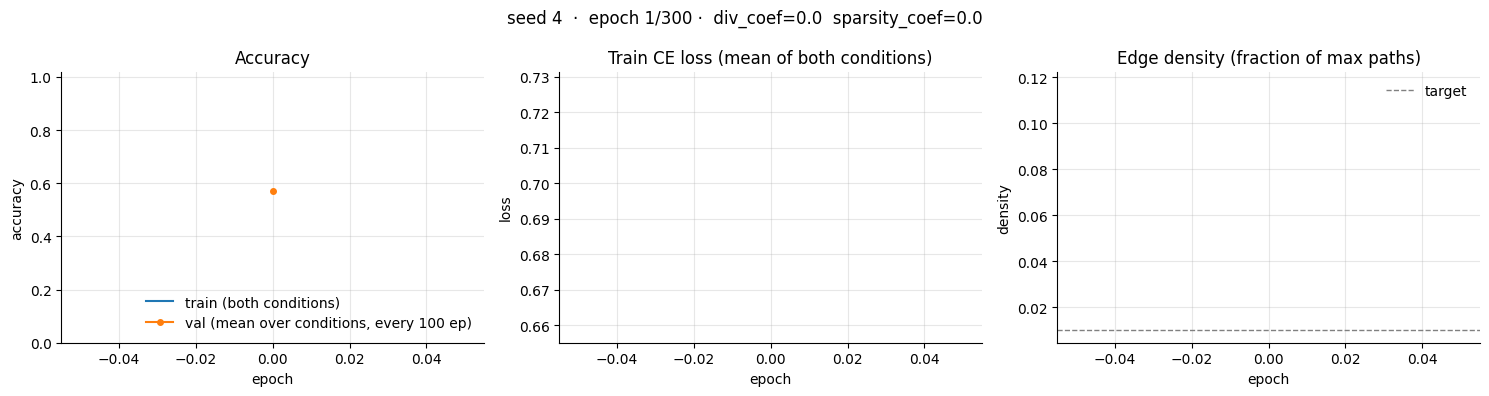

seed 4:   8%|▊         | 25/300 [00:17<03:15,  1.40it/s, acc=0.501, div_raw=0.0000, ent=0.000, loss=0.6932, mask1=0.0, mask2=0.0, sparse=0.0002]    


KeyboardInterrupt: 

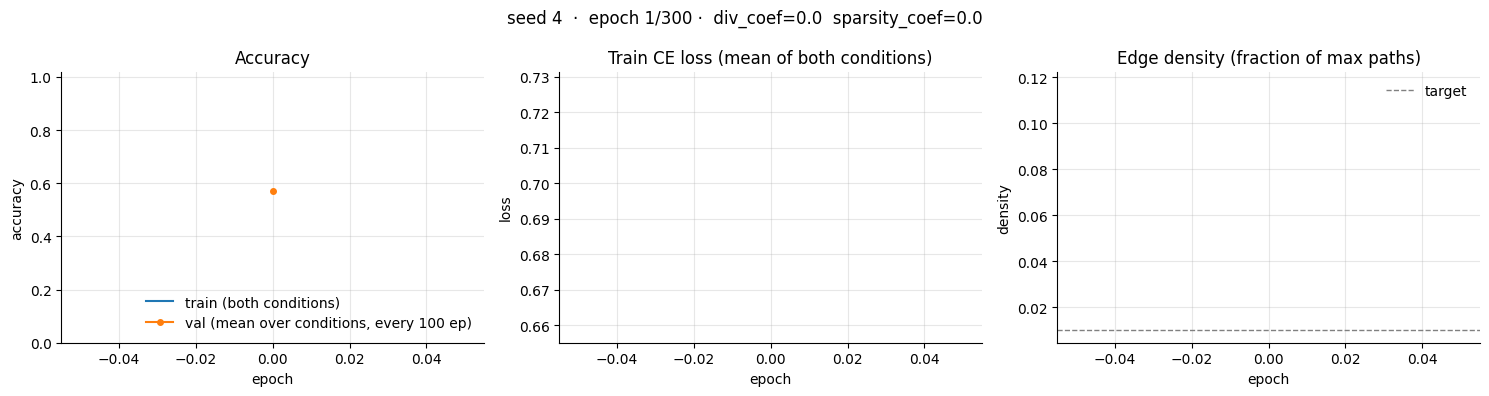

In [104]:
import torch
import numpy as np

args = MaskedArgs()
args.batch_size = 512
args.epochs = 300
args.learning_rate = 3e-4
args.max_grad_norm = 100.0
args.num_train = 4000

args.diversity_coef = 0.0
args.sparsity_coef = 0.0
args.entropy_coef = 0.0
args.mask_bias = 0.5
args.target_density = 0.01
args.loss = 'ce'
args.width = 3
args.num_layers = 3

val_acc_masked_nodiv, test_accs_masked_nodiv, model_masked_nodiv = train_masked(args, seed=4)
print(f"val acc (mean over conditions): {val_acc_masked_nodiv:.3f} | edge density: {model_masked_nodiv.last_density:.3f}")


Averaged over 1000 in-distribution test examples and 8 mask samples
cond |          eta mass on           |       path-mask mass on        | prediction flips when pair is broken (pos / neg) | resample
     |     star/heart   circle/square |     star/heart   circle/square |              star/heart            circle/square |    noise
----------------------------------------------------------------------------------------------------------------------------------
   0 |         514.05         3559.20 |           0.01            0.04 |        0.58 / 0.05              1.00 / 0.00      |     0.00
   1 |         576.41         3309.18 |           0.02            0.04 |        0.58 / 0.04              1.00 / 0.00      |     0.00


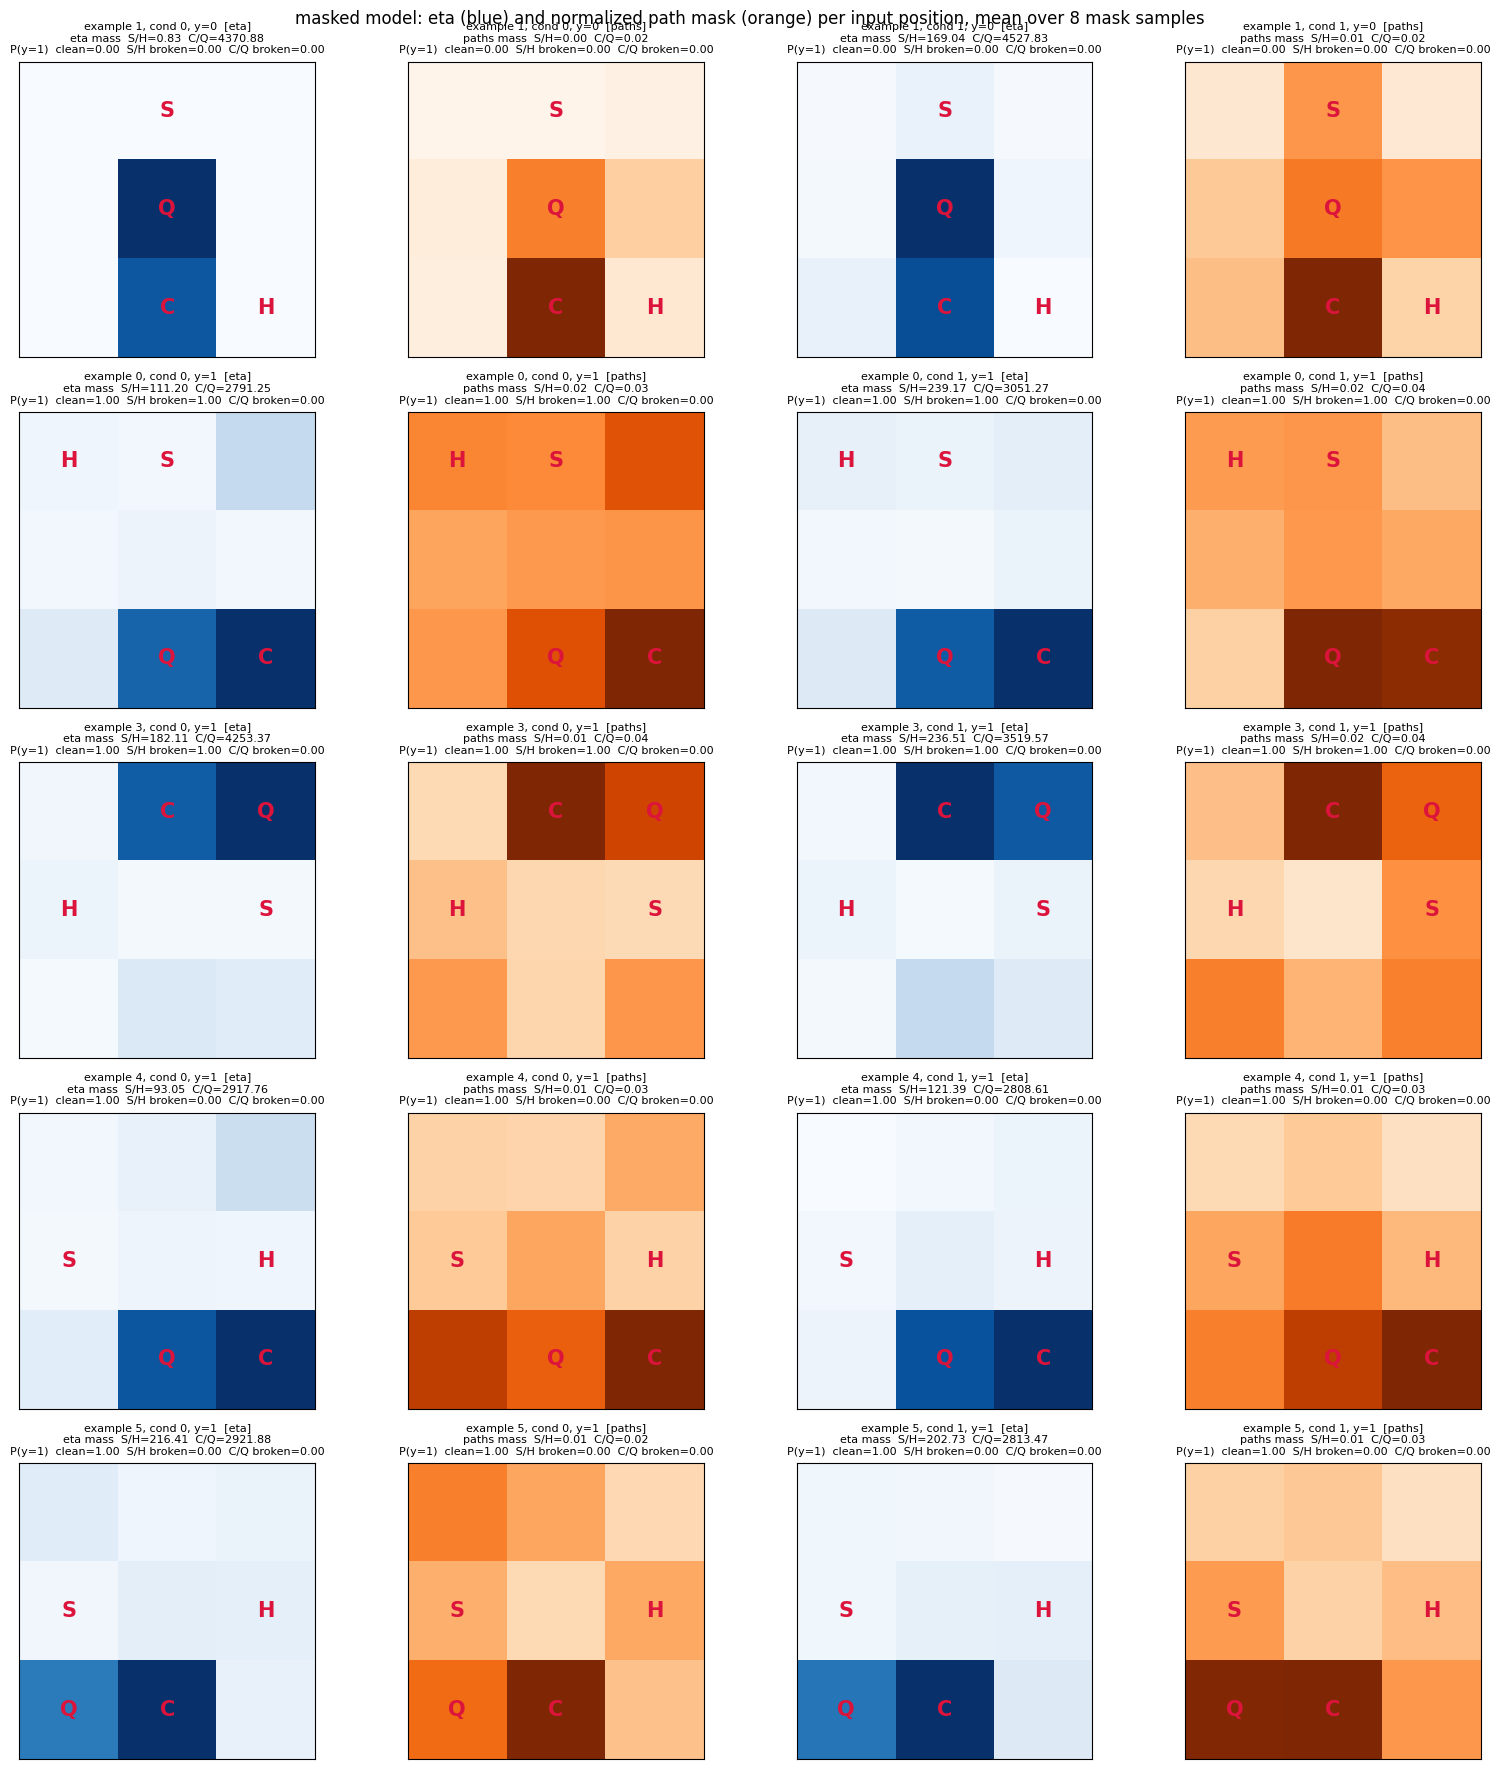

In [58]:
from sparse_generalization.data.shapes.constants import SHAPES_TO_IDX

PAIRS = {'star/heart':    [SHAPES_TO_IDX['star'],   SHAPES_TO_IDX['heart']],
         'circle/square': [SHAPES_TO_IDX['circle'], SHAPES_TO_IDX['square']]}
LETTERS = {SHAPES_TO_IDX['star']: 'S', SHAPES_TO_IDX['heart']: 'H', SHAPES_TO_IDX['circle']: 'C', SHAPES_TO_IDX['square']: 'Q'}

model = model_masked_nodiv
model.eval()
W = model.w   # grid width the model was trained on (set via args.width in the training cell)

# The gumbel edge masks are resampled on every forward pass (hard=True is stochastic
# at any temperature), so eta / paths / probabilities are averaged over n_samples draws,
# and all three are read from the *same* forward pass so they refer to the same masks.
n_samples = 8

def masked_forward(x, c, n=n_samples):
    with torch.no_grad():
        z = model.condition(c)
        etas, paths, probs = [], [], []
        for _ in range(n):
            logits = model(x, z)
            etas.append(model.get_eta().squeeze(1) * model.max_eta[0])
            paths.append(model.get_path_mask(normalize=True).squeeze(1))
            probs.append(torch.sigmoid(logits) if model.loss_type == 'bce' else torch.softmax(logits, -1)[:, 1])
        return torch.stack(etas).mean(0), torch.stack(paths).mean(0), torch.stack(probs).mean(0)

def eta_per_token(x, c):
    return masked_forward(x, c)[0]

def paths_per_token(x, c):
    return masked_forward(x, c)[1]

def p_positive(x, c):
    return masked_forward(x, c)[2]

def on_pair(x, ids):
    return torch.isin(x, torch.tensor(ids, dtype=x.dtype))

def broken(x, ids, seed=0):
    g = torch.Generator().manual_seed(seed)
    x = x.clone()
    w = W
    first = (x == ids[0]).float().argmax(-1); second = (x == ids[1]).float().argmax(-1)
    for i in range(len(x)):
        cells = [j for j in range(w * w) if j // w != first[i].item() // w and j != second[i].item()]
        j = cells[torch.randint(len(cells), (1,), generator=g).item()]
        x[i, second[i]], x[i, j] = x[i, j].item(), x[i, second[i]].item()
    return x

_, _, test_sets_all, _ = get_shapes_datasets(5000, '../data/shapes', W, False)
idx = torch.randperm(len(test_sets_all[0]), generator=torch.Generator().manual_seed(0))[:1000]
X_id = test_sets_all[0].x.flatten(start_dim=1)[idx]
y_id = test_sets_all[0].y.squeeze(-1)[idx]

print(f"Averaged over 1000 in-distribution test examples and {n_samples} mask samples")
print(f"{'cond':>4} | {'eta mass on':^30} | {'path-mask mass on':^30} | {'prediction flips when pair is broken (pos / neg)':^48} | {'resample':>8}")
print(f"{'':>4} | {'star/heart':>14} {'circle/square':>15} | {'star/heart':>14} {'circle/square':>15} | {'star/heart':>23} {'circle/square':>24} | {'noise':>8}")
print("-" * 130)
pos, neg = y_id == 1, y_id == 0
for c in range(2):
    eta, paths, p_clean = masked_forward(X_id, c)
    pred = p_clean > 0.5
    eta_mass = [(eta * on_pair(X_id, ids)).sum(-1).mean().item() for ids in PAIRS.values()]
    path_mass = [(paths * on_pair(X_id, ids)).sum(-1).mean().item() for ids in PAIRS.values()]
    flips = []
    for ids in PAIRS.values():
        flipped = (p_positive(broken(X_id, ids), c) > 0.5) != pred
        flips.append((flipped[pos].float().mean().item(), flipped[neg].float().mean().item()))
    # Flip rate between two independent clean evaluations: how much of a flip is mask noise.
    noise = ((p_positive(X_id, c) > 0.5) != pred).float().mean().item()
    print(f"{c:>4} | {eta_mass[0]:>14.2f} {eta_mass[1]:>15.2f} | {path_mass[0]:>14.2f} {path_mass[1]:>15.2f} | "
          f"{flips[0][0]:>11.2f} / {flips[0][1]:<9.2f} {flips[1][0]:>12.2f} / {flips[1][1]:<9.2f} | {noise:>8.2f}")

# 5 examples: one y=0, the rest y=1 (first of each label in X_id order)
n_show, n_neg = 5, 1
show_idx = torch.cat([torch.where(y_id == 0)[0][:n_neg], torch.where(y_id == 1)[0][:n_show - n_neg]])
fig, axes = plt.subplots(n_show, 4, figsize=(16, 3.6 * n_show))
for r, i in enumerate(show_idx.tolist()):
    x = X_id[i:i + 1]
    for c in range(2):
        eta, paths, p_clean = masked_forward(x, c)
        eta, paths, p_clean = eta[0], paths[0], p_clean.item()
        eta_mass = {name: (eta * on_pair(x, ids)[0]).sum().item() for name, ids in PAIRS.items()}
        path_mass = {name: (paths * on_pair(x, ids)[0]).sum().item() for name, ids in PAIRS.items()}
        p_broken = {name: p_positive(broken(x, ids, seed=r), c).item() for name, ids in PAIRS.items()}
        for k, (name, grid, cmap) in enumerate([('eta', eta, 'Blues'), ('paths', paths, 'Oranges')]):
            ax = axes[r, 2 * c + k]
            ax.imshow(grid.view(W, W), cmap=cmap, vmin=0, vmax=max(grid.max().item(), 1e-6))
            for pos, tok in enumerate(x[0].tolist()):
                if int(tok) in LETTERS:
                    ax.text(pos % W, pos // W, LETTERS[int(tok)],
                            ha='center', va='center', fontsize=15, color='crimson', weight='bold')
            mass = eta_mass if name == 'eta' else path_mass
            ax.set_title(f"example {i}, cond {c}, y={int(y_id[i])}  [{name}]\n"
                         f"{name} mass  S/H={mass['star/heart']:.2f}  C/Q={mass['circle/square']:.2f}\n"
                         f"P(y=1)  clean={p_clean:.2f}  S/H broken={p_broken['star/heart']:.2f}  C/Q broken={p_broken['circle/square']:.2f}",
                         fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"masked model: eta (blue) and normalized path mask (orange) per input position, mean over {n_samples} mask samples")
fig.tight_layout()
